# Definition
Analyzing a simple, linearly damped, sinusoidally forced mass–spring system using different neural network architectures and comparing them using pytorch, numpy, scipy and matplotlib modules. The goal here is to analyze the performance of each architecture to see how well these architectures do when facing a real-world physical problem.

# Physical Parameters
The parameters are chosen as follows:
- $m = 1 kg$
- $c = 0.4 N.s/m$
- $k = 4 N/m$
- $F(t) = 2sin(1.5t)$
- $x(0) = 0$
- $\dot{x}(0) = 0$

# Resulting Governing Equation
These chosen parameters will result in $\ddot{x} + 0.4\dot{x} + 4x = 2sin(1.5 t)$ as the governing equation of this problem's physics.

# Physics In Code
I will first define my physics in code and numericaly solve the governing ODE.

In [1]:
# import modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
# Physical parameters
m = 1.0       # mass [kg]
c = 0.4       # damping coefficient [N*s/m]
k = 4.0       # spring stiffness [N/m]

# External force
F0 = 2.0      # Force amplitude [N]
Omega = 1.5   # Forcing frequency [rad/s]

#initial conditions
x0 = 0.0      # Initial displacement [m]
v0 = 0.0      # Initial velocity [m/s]

# time domain
t_start = 0.0
t_end = 20.0

t = np.linspace(t_start, t_end, 2000)       # 2000 points between 0 and 20 seconds

In [3]:
# define the time dependant forcing function
def force(t):
    
    return F0 * np.sin(Omega * t)

In [4]:
# define the ODE
def mass_spring(t, y):
    
    x = y[0]
    v = y[1]

    dxdt = v
    dvdt = (force(t) - c * v - k * x) / m

    return [dxdt, dvdt]

In [5]:
# numerical solution
solution = solve_ivp(mass_spring, [t_start, t_end], [x0, v0], t_eval=t)

# Check whether the solver succeeded
if not solution.success:
    raise RuntimeError("ODE solver failed.")


# Extract displacement and velocity
x = solution.y[0]
v = solution.y[1]

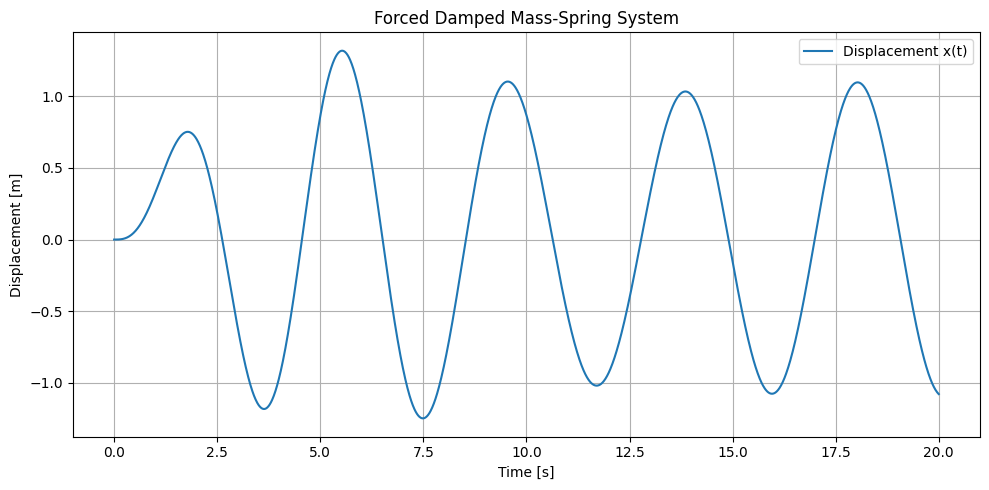

In [6]:
# plot displacement
plt.figure(figsize=(10, 5))

plt.plot(t, x, label="Displacement x(t)")

plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.title("Forced Damped Mass-Spring System")

plt.grid()
plt.legend()
plt.tight_layout()

plt.show()

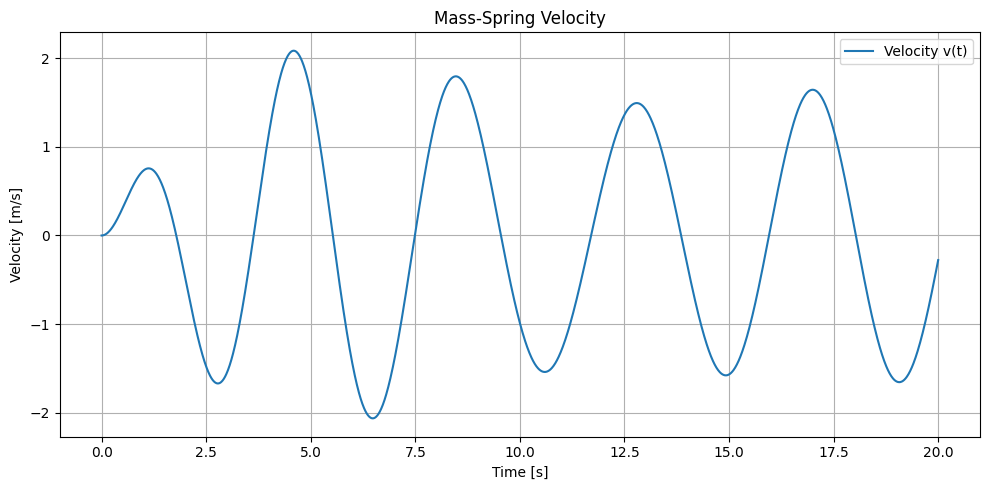

In [7]:
# plot velocity
plt.figure(figsize=(10, 5))

plt.plot(t, v, label="Velocity v(t)")

plt.xlabel("Time [s]")
plt.ylabel("Velocity [m/s]")
plt.title("Mass-Spring Velocity")

plt.grid()
plt.legend()
plt.tight_layout()

plt.show()

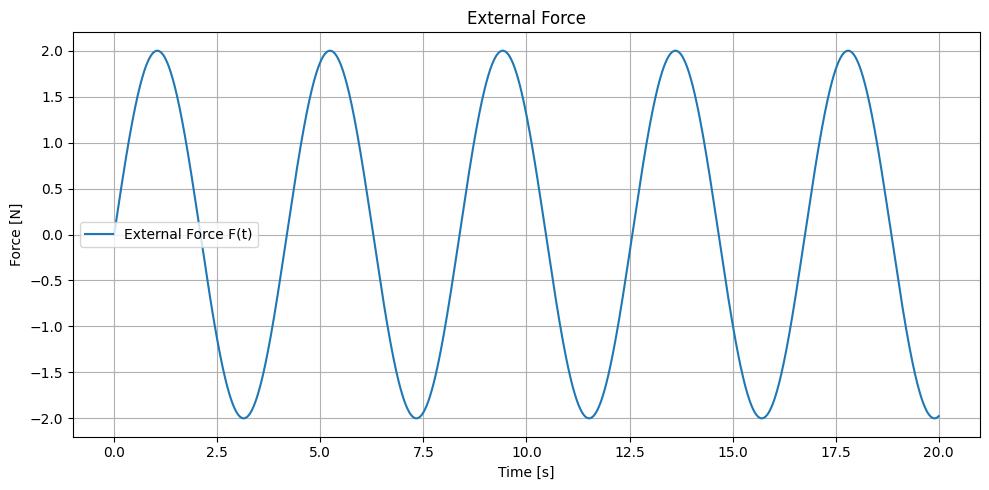

In [8]:
# plot external force
plt.figure(figsize=(10, 5))

plt.plot(t, force(t), label="External Force F(t)")

plt.xlabel("Time [s]")
plt.ylabel("Force [N]")
plt.title("External Force")

plt.grid()
plt.legend()
plt.tight_layout()

plt.show()

In [9]:
# save as dataset
data = np.column_stack(
    (
        t,
        force(t),
        x,
        v
    )
)

np.savetxt(
    "mass_spring_data.csv",
    data,
    delimiter=",",
    header="time,force,displacement,velocity",
    comments=""
)

print()
print("Simulation completed successfully.")
print("Dataset saved as: mass_spring_data.csv")
print()
print(f"Number of time points: {len(t)}")
print(f"Time range: {t_start} to {t_end} seconds")


Simulation completed successfully.
Dataset saved as: mass_spring_data.csv

Number of time points: 2000
Time range: 0.0 to 20.0 seconds


# Analytical Solution
Let's code the analytical solution too and compare it to the numerical solution to check the accuracy.

In [10]:
# define analytical solution
omega_d = np.sqrt(3.96)

A = 1400 / 1369
B = -480 / 1369

C1 = -B
C2 = -0.7356083936

x_analytical = (
    np.exp(-0.2 * t)
    * (
        C1 * np.cos(omega_d * t)
        + C2 * np.sin(omega_d * t)
    )
    + A * np.sin(Omega * t)
    + B * np.cos(Omega * t)
)

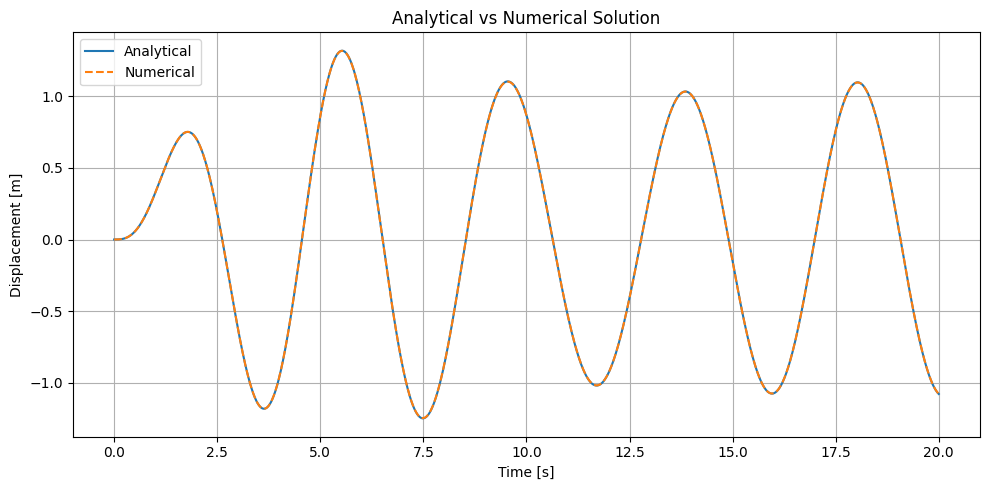

In [11]:
# plot analytical vs numerical
plt.figure(figsize=(10, 5))

plt.plot(
    t,
    x_analytical,
    label="Analytical"
)

plt.plot(
    t,
    x,
    "--",
    label="Numerical"
)

plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.title("Analytical vs Numerical Solution")

plt.grid()
plt.legend()
plt.tight_layout()

plt.show()

In [12]:
# calculate numerical solution's error
max_error = np.max(
    np.abs(x_analytical - x)
)

print(f"Maximum analytical/numerical error: {max_error:.3e} m")

Maximum analytical/numerical error: 1.961e-03 m
